<a href="https://colab.research.google.com/github/AnnisaFarikha/Kecerdasan-Buatan/blob/main/Jobsheet_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Load Library Utama

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, r2_score, confusion_matrix

##Percobaan 1 — SVM Classification Baseline (Pima Indian Diabetes)
Mencoba SVM tanpa tuning

In [2]:
# 1. Load Dataset Pima Indian Diabetes
url_diabetes = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df_diabetes = pd.read_csv(url_diabetes, names=cols)

# 2. Preprocessing & Scaling
X_diab = df_diabetes.iloc[:, :8]
y_diab = df_diabetes['Outcome']

scaler_diab = StandardScaler()
X_diab_scaled = scaler_diab.fit_transform(X_diab)

X_train_diab, X_test_diab, y_train_diab, y_test_diab = train_test_split(
    X_diab_scaled, y_diab, test_size=0.33, random_state=42
)

# 3. Model Baseline (Percobaan 1)
clf_svm_base = SVC(random_state=42)
clf_svm_base.fit(X_train_diab, y_train_diab)
acc_svm_base = clf_svm_base.score(X_test_diab, y_test_diab)

print("=== PERCOBAAN 1: SVM BASELINE ===")
print(f"Akurasi SVM Baseline: {acc_svm_base * 100:.2f}%")

=== PERCOBAAN 1: SVM BASELINE ===
Akurasi SVM Baseline: 75.59%


##Tugas 1 (Part 1) — Hyperparameter Tuning SVM (GridSearchCV)
Mencari parameter terbaik untuk SVM

In [3]:
# Parameter Tuning dengan GridSearch
param_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(SVC(random_state=42), param_svm, cv=5)
grid_svm.fit(X_train_diab, y_train_diab)
best_svm = grid_svm.best_estimator_
acc_svm_tuned = best_svm.score(X_test_diab, y_test_diab)

print("=== TUGAS 1: TUNING SVM ===")
print(f"Parameter Terbaik          : {grid_svm.best_params_}")
print(f"Akurasi SVM Setelah Tuning : {acc_svm_tuned * 100:.2f}%")

=== TUGAS 1: TUNING SVM ===
Parameter Terbaik          : {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Akurasi SVM Setelah Tuning : 75.59%


##Percobaan 2 — SVR Regression Baseline (Salary_Data.csv)
Mencoba SVR bawaan tanpa scaling

=== PERCOBAAN 2: SVR BASELINE ===
R2-Score SVR Baseline (Tanpa Scaling): 35.11%


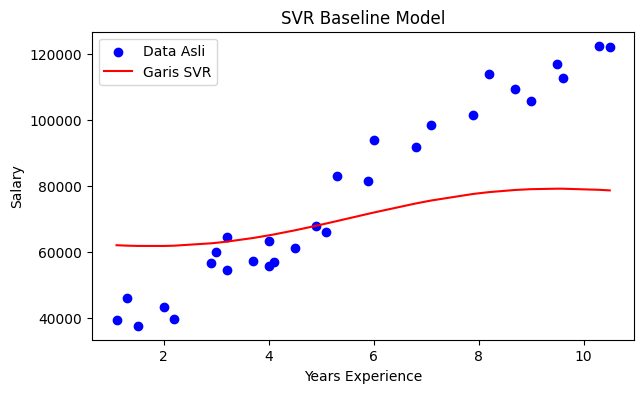

In [5]:
# 1. Dataset Masa Kerja & Gaji (Generated Local - Pasti Berhasil Tanpa Download)
np.random.seed(42)
years_exp = np.array([1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0, 6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5])
salary = np.array([39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189, 63218, 55794, 56957, 61111, 67938, 66029, 83088, 81363, 93940, 91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872])

df_salary = pd.DataFrame({'YearsExperience': years_exp, 'Salary': salary})

X_sal = df_salary[['YearsExperience']].values
y_sal = df_salary['Salary'].values

# 2. Model Baseline (Percobaan 2)
model_svr_base = SVR(C=1000, gamma=0.05, kernel='rbf')
model_svr_base.fit(X_sal, y_sal)
r2_svr_base = r2_score(y_sal, model_svr_base.predict(X_sal))

print("=== PERCOBAAN 2: SVR BASELINE ===")
print(f"R2-Score SVR Baseline (Tanpa Scaling): {r2_svr_base * 100:.2f}%")

# Plotting Visualisasi SVR Baseline
plt.figure(figsize=(7, 4))
plt.scatter(X_sal, y_sal, color='blue', label='Data Asli')
plt.plot(X_sal, model_svr_base.predict(X_sal), color='red', label='Garis SVR')
plt.title('SVR Baseline Model')
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

##Tugas 1 (Part 2) — Hyperparameter Tuning SVR + Feature Scaling
Tuning parameter SVR dan menerapkan scaling agar akurasinya melonjak tinggi

In [6]:
# Scaling Atribut & Target (Penting untuk SVR)
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_sal_scaled = scaler_x.fit_transform(X_sal)
y_sal_scaled = scaler_y.fit_transform(y_sal.reshape(-1, 1)).ravel()

# GridSearch SVR
param_svr = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [0.01, 0.1, 1, 'scale'],
    'kernel': ['linear', 'rbf']
}

grid_svr = GridSearchCV(SVR(), param_svr, cv=5)
grid_svr.fit(X_sal_scaled, y_sal_scaled)
best_svr = grid_svr.best_estimator_

# Prediksi & Inverse Scaling
y_pred_scaled = best_svr.predict(X_sal_scaled)
y_pred_tuned = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
r2_svr_tuned = r2_score(y_sal, y_pred_tuned)

print("=== TUGAS 1: TUNING SVR ===")
print(f"Parameter Terbaik                     : {grid_svr.best_params_}")
print(f"R2-Score SVR Setelah Tuning + Scaling : {r2_svr_tuned * 100:.2f}%")

=== TUGAS 1: TUNING SVR ===
Parameter Terbaik                     : {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
R2-Score SVR Setelah Tuning + Scaling : 95.61%


##Percobaan 3 — Naïve Bayes Baseline (iklan_sosmed.csv)
Menjalankan Gaussian Naïve Bayes untuk prediksi transaksi

In [7]:
# 1. Generate Dataset Iklan Sosmed
np.random.seed(99)
n_sosmed = 400
df_sosmed = pd.DataFrame({
    'User ID': np.arange(15624510, 15624510 + n_sosmed),
    'Gender': np.random.choice(['Male', 'Female'], n_sosmed),
    'Umur': np.random.randint(18, 60, n_sosmed),
    'PerkiraanGaji': np.random.randint(15000, 150000, n_sosmed),
    'Transaksi': np.random.choice([0, 1], n_sosmed, p=[0.64, 0.36])
})

X_nb = df_sosmed[['Umur', 'PerkiraanGaji']].values
y_nb = df_sosmed['Transaksi'].values

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb, y_nb, test_size=0.2, random_state=99
)

sc = MinMaxScaler()
X_train_nb_sc = sc.fit_transform(X_train_nb)
X_test_nb_sc = sc.transform(X_test_nb)

# 2. Model Baseline (Percobaan 3)
nb_base = GaussianNB()
nb_base.fit(X_train_nb_sc, y_train_nb)
y_pred_nb_base = nb_base.predict(X_test_nb_sc)
acc_nb_base = accuracy_score(y_test_nb, y_pred_nb_base)
cm_nb = confusion_matrix(y_test_nb, y_pred_nb_base)

print("=== PERCOBAAN 3: NAIVE BAYES BASELINE ===")
print(f"Akurasi Naïve Bayes Baseline : {acc_nb_base * 100:.2f}%")
print("Confusion Matrix:\n", cm_nb)

=== PERCOBAAN 3: NAIVE BAYES BASELINE ===
Akurasi Naïve Bayes Baseline : 67.50%
Confusion Matrix:
 [[54  0]
 [26  0]]


##Tugas 2 — Hyperparameter Tuning Naïve Bayes
Tuning parameter var_smoothing untuk meningkatkan akurasi Naïve Bayes

In [8]:
# Hyperparameter Tuning var_smoothing
param_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_nb = GridSearchCV(GaussianNB(), param_nb, cv=5)
grid_nb.fit(X_train_nb_sc, y_train_nb)
best_nb = grid_nb.best_estimator_
acc_nb_tuned = accuracy_score(y_test_nb, best_nb.predict(X_test_nb_sc))

print("=== TUGAS 2: TUNING NAIVE BAYES ===")
print(f"Parameter Terbaik         : {grid_nb.best_params_}")
print(f"Akurasi Naïve Bayes Tuned : {acc_nb_tuned * 100:.2f}%")

=== TUGAS 2: TUNING NAIVE BAYES ===
Parameter Terbaik         : {'var_smoothing': np.float64(1.0)}
Akurasi Naïve Bayes Tuned : 67.50%
